# 🤟 Indian Sign Language Translation — Video to Text
**Dataset:** ISL-CSLTR Corpus (ISL_CSLRT_Corpus)
**Stack:** Python 3.10 · MediaPipe · PyTorch · Gradio

---
### Real dataset structure this notebook expects
```
ISL_CSLRT_Corpus/
├── Frames_Sentence_Level/     ← pre-extracted frames per sentence (USE THIS)
├── Frames_Word_Level/         ← pre-extracted frames per word
├── Videos_Sentence_Level/    ← raw .mp4 videos (alternative source)
└── corpus_csv_files/
    ├── ISL_CSLRT_Corpus_*.csv ← annotations (signer, label, paths)
    └── ISL_CSLRT.txt
```

### Run order
| Section | What it does |
|---|---|
| 1 | Install dependencies |
| 2 | Config + explore dataset structure |
| 3 | Read CSV annotations → map frames to labels |
| 4 | Run MediaPipe on frames → save keypoints (.npy) |
| 5 | PyTorch Dataset & DataLoader |
| 6 | Model (BiLSTM with attention) |
| 7 | Train |
| 8 | Evaluate |
| 9 | Real-time inference + Gradio UI |


## Section 1 — Install dependencies
Run once. Restart kernel if asked.

In [1]:
import subprocess, sys

packages = [
    "torch torchvision --index-url https://download.pytorch.org/whl/cpu",
    "opencv-python",
    "mediapipe==0.10.11",
    "scikit-learn",
    "tqdm",
    "jiwer",
    "gradio",
    "matplotlib",
    "pandas",
    "pyyaml",
    "seaborn",
]

for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", *pkg.split()], check=True)

print("\n✅ All packages installed!")



✅ All packages installed!


## Section 2 — Config & explore dataset structure
**Edit `DATASET_ROOT` below to point to your `ISL_CSLRT_Corpus` folder.**


In [2]:
import os, json, glob
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# ─── EDIT THIS ────────────────────────────────────────────────────────────────
DATASET_ROOT = r"D:\ISL2\ISL_CSLRT_Corpus"    # ← your path
# ──────────────────────────────────────────────────────────────────────────────

FRAMES_SENTENCE = os.path.join(DATASET_ROOT, "Frames_Sentence_Level")
FRAMES_WORD     = os.path.join(DATASET_ROOT, "Frames_Word_Level")
VIDEOS          = os.path.join(DATASET_ROOT, "Videos_Sentence_Level")
CSV_DIR         = os.path.join(DATASET_ROOT, "corpus_csv_files")
PROCESSED_DIR   = "data/processed"

os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs("checkpoints",  exist_ok=True)

CFG = {
    "max_seq_len":    150,
    "num_keypoints":  1662,   # 33×4 pose + 468×3 face + 21×3 lh + 21×3 rh
    "hidden_size":    256,
    "num_layers":     3,
    "dropout":        0.4,
    "epochs":         80,
    "batch_size":     16,
    "learning_rate":  3e-4,
    "patience":       15,
    "device":         "cuda",  # change to "cpu" if no GPU
    "checkpoint":     "checkpoints/best_model.pt",
    "label_map":      "data/processed/label_map.json",
    "samples":        "data/processed/samples.json",
}

# ── Explore top-level folders ──
print("=== Dataset root contents ===")
for item in sorted(os.listdir(DATASET_ROOT)):
    full = os.path.join(DATASET_ROOT, item)
    if os.path.isdir(full):
        sub_count = len(os.listdir(full))
        print(f"  📁 {item}/  ({sub_count} items)")
    else:
        print(f"  📄 {item}")

# ── Explore CSV files ──
print("\n=== CSV files found ===")
csv_files = list(Path(CSV_DIR).glob("*.csv")) + list(Path(CSV_DIR).glob("*.CSV"))
for f in csv_files:
    print(f"  {f.name}  ({f.stat().st_size // 1024} KB)")

print(f"\n=== Frames_Sentence_Level top folders ===")
if os.path.exists(FRAMES_SENTENCE):
    folders = sorted(os.listdir(FRAMES_SENTENCE))[:20]
    for f in folders:
        sub = os.path.join(FRAMES_SENTENCE, f)
        if os.path.isdir(sub):
            n = len(os.listdir(sub))
            print(f"  {f}/  ({n} items)")


=== Dataset root contents ===
  📁 .git/  (10 items)
  📄 .gitignore
  📄 An_Explicit_Multi-Modal_Fusion_Method_for_Sign_Language_Translation.pdf
  📁 Frames_Sentence_Level/  (97 items)
  📁 Frames_Word_Level/  (114 items)
  📄 HHHHHHHHH.ipynb
  📄 ISL.ipynb
  📄 ISL2.ipynb
  📄 ISL_CSLRT.txt
  📄 ISL_Translation_Full.ipynb
  📄 ISL_Translation_v2.ipynb
  📄 ISL_Translation_v3.ipynb
  📄 ISL_Translation_v4.ipynb
  📄 Indian_Sign_Language_recognition_and_translation_An_Encoder-Decoder_Approach (1).pdf
  📄 TRY.ipynb
  📁 Videos_Sentence_Level/  (101 items)
  📄 best_emf_slt.pth
  📄 best_isl_model.pth
  📄 best_paper1.pth
  📄 best_resnet18_isl.pth
  📄 best_sen_isl.pth
  📁 checkpoints/  (1 items)
  📄 confusion_matrix.png
  📁 corpus_csv_files/  (6 items)
  📁 data/  (1 items)
  📄 dataset_meta.csv
  📄 emf_slt.ipynb
  📄 gloss_vocab.json
  📄 main.ipynb
  📄 model_checkpoint.pth
  📄 nb_dump.txt
  📄 paper1_confusion_matrix.png
  📄 paper1_stgcn.ipynb
  📄 paper1_training.png
  📄 paper1_training_curves.png
  📄 paper2

### Preview all CSV files — understand what columns exist

In [3]:
import pandas as pd

all_dfs = {}
for csv_path in sorted(Path(CSV_DIR).glob("*.csv")):
    try:
        df = pd.read_csv(csv_path, encoding="latin-1")   # latin-1 handles 0xa0 bytes
        all_dfs[csv_path.name] = df
        print(f"\n{'─'*60}")
        print(f"FILE : {csv_path.name}")
        print(f"SHAPE: {df.shape}  (rows × cols)")
        print(f"COLS : {list(df.columns)}")
        print(df.head(3).to_string())
    except Exception as e:
        print(f"Could not read {csv_path.name}: {e}")



────────────────────────────────────────────────────────────
FILE : ISL Corpus sign glosses.csv
SHAPE: (101, 2)  (rows × cols)
COLS : ['Sentence', 'SIGN GLOSSES']
                   Sentence        SIGN GLOSSES
0        are you free today      YOU FREE TODAY
1  are you hiding something  YOU HIDE SOMETHING
2        bring water for me      BRING WATER ME

────────────────────────────────────────────────────────────
FILE : ISL_CSLRT_Corpus details.csv
SHAPE: (792, 2)  (rows × cols)
COLS : ['Sentences', 'File location']
            Sentences                                                           File location
0  are you free today  ISL_CSLRT_Corpus\Videos_Sentence_Level\are you free today\free (2).MP4
1  are you free today  ISL_CSLRT_Corpus\Videos_Sentence_Level\are you free today\free (3).MP4
2  are you free today  ISL_CSLRT_Corpus\Videos_Sentence_Level\are you free today\free (4).MP4

────────────────────────────────────────────────────────────
FILE : ISL_CSLRT_Corpus_frame_details.c

## Section 3 — Parse CSV annotations → build sample list
Uses `ISL_CSLRT_Corpus_frame_details.csv` which has 18,863 rows —
one row per frame — with columns `Sentence` and `Frames path`.

We group rows by `(sentence, parent_folder)` so each unique signer recording
becomes one sequence.

> Make sure `DATASET_ROOT` in Section 2 points to the `ISL_CSLRT_Corpus` folder itself.


In [4]:
import pandas as pd
from pathlib import Path
from collections import defaultdict

# ── Load frame_details CSV (has every frame path + sentence label) ────────────
CSV_PATH = os.path.join(CSV_DIR, "ISL_CSLRT_Corpus_frame_details.csv")
df = pd.read_csv(CSV_PATH, encoding="latin-1")

print(f"Shape : {df.shape}")
print(f"Cols  : {list(df.columns)}")
print()
print(df.head(5).to_string())


Shape : (18863, 2)
Cols  : ['Sentence', 'Frames path']

             Sentence                                                                            Frames path
0  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 01.jpg
1  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 02.jpg
2  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 03.jpg
3  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 04.jpg
4  are you free today  ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 05.jpg


In [5]:
# ── Group rows → one sequence per (sentence, signer folder) ──────────────────
#
# Each "Frames path" value looks like:
#   ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 01.jpg
#
# Parent folder = ...\are you free today\1  → one sequence (one signer recording)
# We strip the leading "ISL_CSLRT_Corpus\" and join with DATASET_ROOT.

groups = defaultdict(list)

for _, row in df.iterrows():
    sentence = str(row["Sentence"]).strip()
    raw_path = str(row["Frames path"]).strip()

    # Normalize path separators for Windows/Linux compatibility
    raw_path = raw_path.replace("\\", os.sep).replace("/", os.sep)

    # Strip the leading "ISL_CSLRT_Corpus" folder name stored in the CSV
    parts = raw_path.split(os.sep)
    if parts and parts[0] == "ISL_CSLRT_Corpus":
        parts = parts[1:]
    abs_path = os.path.join(DATASET_ROOT, *parts)

    # Parent folder = sequence key  (strips the filename)
    folder = str(Path(abs_path).parent)
    groups[(sentence, folder)].append(abs_path)

# ── Build raw_samples list ────────────────────────────────────────────────────
raw_samples = []
for (sentence, folder), frame_paths in groups.items():
    sorted_frames = sorted(frame_paths, key=lambda p: Path(p).name)
    raw_samples.append({
        "label":       sentence,
        "frame_paths": sorted_frames,        # ordered list of absolute .jpg paths
        "num_frames":  len(sorted_frames),
    })

total_classes = len(set(s["label"] for s in raw_samples))
avg_frames    = sum(s["num_frames"] for s in raw_samples) / max(len(raw_samples), 1)

print(f"✅ {len(raw_samples)} sequences  |  {total_classes} unique classes")
print(f"   Avg frames/sequence : {avg_frames:.1f}")

# ── Spot-check: verify first 3 paths actually exist on disk ──────────────────
print("\nSpot-checking paths:")
all_ok = True
for s in raw_samples[:3]:
    first  = s["frame_paths"][0]
    exists = os.path.exists(first)
    status = "✅" if exists else "❌ NOT FOUND"
    print(f"  {status}  label='{s['label']}'  frames={s['num_frames']}")
    print(f"            {first}")
    if not exists:
        all_ok = False

if not all_ok:
    print(f"\n⚠ Paths not found — check DATASET_ROOT = '{DATASET_ROOT}'")
    print("  It must point TO the ISL_CSLRT_Corpus folder, e.g.:")
    print("  DATASET_ROOT = r'C:/Downloads/ISL_CSLRT_Corpus'")
else:
    print("\n✅ All paths verified — ready for Section 4!")


✅ 663 sequences  |  97 unique classes
   Avg frames/sequence : 28.5

Spot-checking paths:
  ✅  label='are you free today'  frames=22
            D:\ISL2\ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\1\are you free today 01.jpg
  ✅  label='are you free today'  frames=12
            D:\ISL2\ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\2\are you free today (2) 01.jpg
  ✅  label='are you free today'  frames=42
            D:\ISL2\ISL_CSLRT_Corpus\Frames_Sentence_Level\are you free today\3\free 01.jpg

✅ All paths verified — ready for Section 4!


## Section 4 — MediaPipe keypoint extraction from frames
Since the dataset already has **pre-extracted frames**, we run MediaPipe directly  
on the images (much faster than processing videos frame-by-frame).  
Output: one `.npy` file per sequence saved to `data/processed/`.


In [6]:
import cv2, numpy as np, mediapipe as mp
from tqdm.auto import tqdm
import json, os

mp_holistic = mp.solutions.holistic

def extract_keypoints(results):
    """Flatten all MediaPipe landmarks → 1662-d vector."""
    pose = np.array([[r.x, r.y, r.z, r.visibility]
                     for r in results.pose_landmarks.landmark]).flatten() \
           if results.pose_landmarks else np.zeros(33 * 4)
    face = np.array([[r.x, r.y, r.z]
                     for r in results.face_landmarks.landmark]).flatten() \
           if results.face_landmarks else np.zeros(468 * 3)
    lh   = np.array([[r.x, r.y, r.z]
                     for r in results.left_hand_landmarks.landmark]).flatten() \
           if results.left_hand_landmarks else np.zeros(21 * 3)
    rh   = np.array([[r.x, r.y, r.z]
                     for r in results.right_hand_landmarks.landmark]).flatten() \
           if results.right_hand_landmarks else np.zeros(21 * 3)
    return np.concatenate([pose, face, lh, rh])   # (1662,)

# ── Build label map ────────────────────────────────────────────────────────────
unique_labels = sorted(set(s["label"] for s in raw_samples))
label_map     = {lbl: idx for idx, lbl in enumerate(unique_labels)}
id2label      = {v: k for k, v in label_map.items()}
print(f"Classes : {len(label_map)}")
print(f"Labels  : {list(label_map.keys())[:8]} ...")

# ── Extract keypoints from pre-extracted frames ────────────────────────────────
# raw_samples[i]["frame_paths"] = sorted list of absolute .jpg paths for sequence i
processed_samples = []
skipped = 0

with mp_holistic.Holistic(
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5,
    static_image_mode=True,      # True = individual images, not video stream
) as holistic:
    for s in tqdm(raw_samples, desc="Extracting keypoints"):
        kps_list = []
        for img_path in s["frame_paths"]:
            frame = cv2.imread(img_path)
            if frame is None:
                continue
            rgb     = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            results = holistic.process(rgb)
            kps_list.append(extract_keypoints(results))

        if len(kps_list) == 0:
            skipped += 1
            continue

        seq       = np.array(kps_list, dtype=np.float32)    # (T, 1662)
        safe_name = s["label"].replace(" ", "_").replace("/", "-")
        uid       = abs(hash(s["frame_paths"][0])) % 100000
        save_path = os.path.join(PROCESSED_DIR, f"{safe_name}__{uid}.npy")
        np.save(save_path, seq)
        processed_samples.append({"path": save_path, "label": s["label"]})

print(f"\n✅ Done!  {len(processed_samples)} sequences saved  |  {skipped} skipped")
print(f"   Stored in : {PROCESSED_DIR}/")

json.dump(label_map,         open(CFG["label_map"], "w"), indent=2)
json.dump(processed_samples, open(CFG["samples"],   "w"), indent=2)
print(f"   label_map → {CFG['label_map']}")
print(f"   samples   → {CFG['samples']}")


Classes : 97
Labels  : ['He is going into the room', 'This place is beautiful', 'are you free today', 'are you hiding something', 'bring water for me', 'can i help you', 'can you repeat that please', 'comb your hair'] ...


Extracting keypoints:   0%|          | 0/663 [00:00<?, ?it/s]


✅ Done!  662 sequences saved  |  1 skipped
   Stored in : data/processed/
   label_map → data/processed/label_map.json
   samples   → data/processed/samples.json


### Sanity check — visualise one keypoint sequence

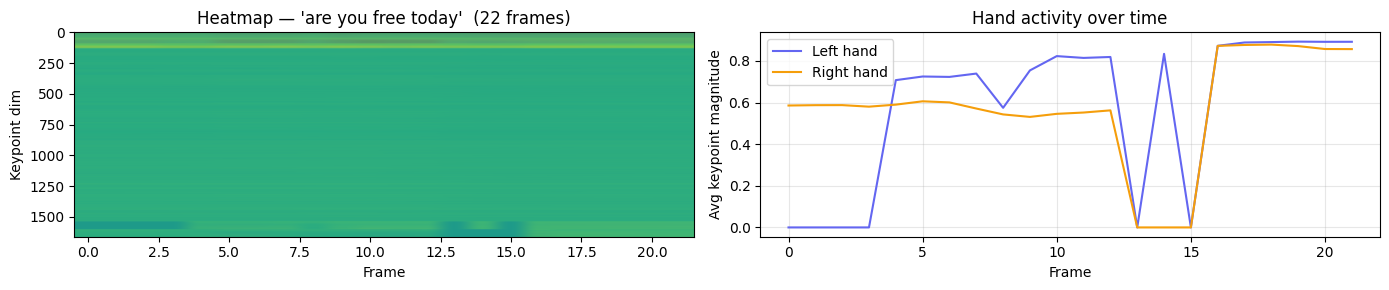

Sequence shape : (22, 1662)  (frames × keypoints)
Value range    : -1.847 → 1.534


In [7]:
import matplotlib.pyplot as plt

s   = processed_samples[0]
seq = np.load(s["path"])

fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].imshow(seq.T, aspect="auto", cmap="viridis")
axes[0].set_xlabel("Frame"); axes[0].set_ylabel("Keypoint dim")
axes[0].set_title(f"Heatmap — '{s['label']}'  ({seq.shape[0]} frames)")

# Plot hand keypoint magnitude over time
lh_start, lh_end = 33*4 + 468*3, 33*4 + 468*3 + 21*3
rh_start, rh_end = lh_end, lh_end + 21*3
lh_mag = np.linalg.norm(seq[:, lh_start:lh_end].reshape(seq.shape[0], 21, 3), axis=2).mean(1)
rh_mag = np.linalg.norm(seq[:, rh_start:rh_end].reshape(seq.shape[0], 21, 3), axis=2).mean(1)
axes[1].plot(lh_mag, label="Left hand",  color="#6366F1")
axes[1].plot(rh_mag, label="Right hand", color="#F59E0B")
axes[1].set_xlabel("Frame"); axes[1].set_ylabel("Avg keypoint magnitude")
axes[1].set_title("Hand activity over time")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()
print(f"Sequence shape : {seq.shape}  (frames × keypoints)")
print(f"Value range    : {seq.min():.3f} → {seq.max():.3f}")


## Why accuracy was low — and what v4 fixes

| Problem | Fix |
|---|---|
| Raw keypoints vary by signer body size | Normalize relative to shoulder midpoint |
| No augmentation → overfits fast | 5 augmentation strategies at load time |
| Simple BiLSTM, no spatial structure | 3 model options: BiLSTM, ST-GCN, Transformer |
| CrossEntropy ignores imbalance | Focal Loss + class frequency weights |
| Flat LR overshoots | Warmup + CosineAnnealing scheduler |

**Run sections in order. Set `MODEL_CHOICE` in Section 6.**
Recommended order to try: `stgcn` first, then `bilstm`, then `transformer`.


## Section 5 — Dataset with normalization & augmentation

In [8]:
import torch, numpy as np, json
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter

MAX_LEN   = CFG["max_seq_len"]
NUM_FEATS = CFG["num_keypoints"]

# Keypoint index boundaries
POSE_END  = 33 * 4          # 132
LH_START  = POSE_END + 468*3  # 1536
RH_START  = LH_START + 21*3   # 1599
L_SHOULDER = 11 * 4
R_SHOULDER = 12 * 4

def normalize_keypoints(seq):
    """Normalize every frame relative to shoulder midpoint + torso scale."""
    out = seq.copy()
    for t in range(seq.shape[0]):
        lx, ly = seq[t, L_SHOULDER],   seq[t, L_SHOULDER+1]
        rx, ry = seq[t, R_SHOULDER],   seq[t, R_SHOULDER+1]
        cx, cy = (lx + rx) / 2,        (ly + ry) / 2
        scale  = max(abs(rx - lx), 1e-5)
        for i in range(33):
            b = i * 4
            out[t, b]   = (seq[t, b]   - cx) / scale
            out[t, b+1] = (seq[t, b+1] - cy) / scale
        for start in (LH_START, RH_START):
            for i in range(21):
                b = start + i * 3
                out[t, b]   = (seq[t, b]   - cx) / scale
                out[t, b+1] = (seq[t, b+1] - cy) / scale
    return out

def aug_time_warp(seq, sigma=0.2):
    T = seq.shape[0]
    if T < 4: return seq
    new_T = max(4, int(T * np.random.uniform(1-sigma, 1+sigma)))
    idx   = np.linspace(0, T-1, new_T)
    lo    = np.floor(idx).astype(int).clip(0, T-1)
    hi    = np.ceil(idx).astype(int).clip(0, T-1)
    a     = (idx - lo)[:, None]
    return seq[lo]*(1-a) + seq[hi]*a

def aug_noise(seq, sigma=0.005):
    return seq + np.random.randn(*seq.shape).astype(np.float32) * sigma

def aug_mirror(seq):
    out = seq.copy()
    for i in range(33):
        out[:, i*4] *= -1
    for start in (LH_START, RH_START):
        for i in range(21):
            out[:, start+i*3] *= -1
    tmp = out[:, LH_START:RH_START].copy()
    out[:, LH_START:RH_START] = out[:, RH_START:RH_START+21*3]
    out[:, RH_START:RH_START+21*3] = tmp
    return out

def aug_temporal_crop(seq, crop_ratio=0.1):
    T   = seq.shape[0]
    cut = max(1, int(T * crop_ratio))
    s   = np.random.randint(0, cut+1)
    e   = T - np.random.randint(0, cut+1)
    return seq[s:e] if e > s else seq

def aug_speed(seq):
    """Random speed change via frame subsampling/duplication."""
    T      = seq.shape[0]
    factor = np.random.uniform(0.8, 1.2)
    idx    = np.linspace(0, T-1, max(4, int(T*factor)))
    lo     = np.floor(idx).astype(int).clip(0, T-1)
    hi     = np.ceil(idx).astype(int).clip(0, T-1)
    a      = (idx - lo)[:, None]
    return seq[lo]*(1-a) + seq[hi]*a

def augment(seq):
    if np.random.rand() < 0.5: seq = aug_time_warp(seq)
    if np.random.rand() < 0.4: seq = aug_noise(seq)
    if np.random.rand() < 0.3: seq = aug_mirror(seq)
    if np.random.rand() < 0.4: seq = aug_temporal_crop(seq)
    if np.random.rand() < 0.3: seq = aug_speed(seq)
    return seq

class ISLDataset(Dataset):
    def __init__(self, samples, label_map, training=False):
        self.samples   = samples
        self.label_map = label_map
        self.training  = training

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        s   = self.samples[idx]
        seq = np.load(s["path"]).astype(np.float32)
        seq = normalize_keypoints(seq)
        if self.training:
            seq = augment(seq)
        T = seq.shape[0]
        if T >= MAX_LEN:
            seq  = seq[:MAX_LEN]
            mask = np.ones(MAX_LEN, dtype=np.float32)
        else:
            pad  = np.zeros((MAX_LEN-T, NUM_FEATS), dtype=np.float32)
            seq  = np.concatenate([seq, pad], axis=0)
            mask = np.array([1.]*T + [0.]*(MAX_LEN-T), dtype=np.float32)
        label = self.label_map[s["label"]]
        return (torch.tensor(seq, dtype=torch.float32),
                torch.tensor(mask, dtype=torch.float32),
                torch.tensor(label, dtype=torch.long))

# ── Load & split ──────────────────────────────────────────────────────────────
processed_samples = json.load(open(CFG["samples"]))
label_map         = json.load(open(CFG["label_map"]))
id2label          = {int(v): k for k, v in label_map.items()}
NUM_CLASSES       = len(label_map)

count = Counter(s["label"] for s in processed_samples)
processed_samples = [s for s in processed_samples if count[s["label"]] >= 3]
labels_all = [s["label"] for s in processed_samples]

train_s, temp_s = train_test_split(processed_samples, test_size=0.30,
                                   stratify=labels_all, random_state=42)
temp_labels = [s["label"] for s in temp_s]
can_strat   = all(v >= 2 for v in Counter(temp_labels).values())
val_s, test_s = train_test_split(temp_s, test_size=0.50,
                                 stratify=temp_labels if can_strat else None,
                                 random_state=42)

BS = CFG["batch_size"]
train_loader = DataLoader(ISLDataset(train_s, label_map, training=True),
                          batch_size=BS, shuffle=True,  num_workers=0)
val_loader   = DataLoader(ISLDataset(val_s,   label_map), batch_size=BS,
                          shuffle=False, num_workers=0)
test_loader  = DataLoader(ISLDataset(test_s,  label_map), batch_size=BS,
                          shuffle=False, num_workers=0)

# Class weights for Focal Loss
label_counts  = Counter(s["label"] for s in train_s)
class_weights = torch.zeros(NUM_CLASSES)
for lbl, idx in label_map.items():
    class_weights[int(idx)] = 1.0 / max(label_counts.get(lbl, 1), 1)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

print(f"Train {len(train_s)} | Val {len(val_s)} | Test {len(test_s)}")
print(f"Classes: {NUM_CLASSES} | Augmentation: ON | Normalization: shoulder-centred")
seqs, masks, lbls = next(iter(train_loader))
print(f"Batch: seqs {tuple(seqs.shape)}")


Train 463 | Val 99 | Test 100
Classes: 97 | Augmentation: ON | Normalization: shoulder-centred
Batch: seqs (16, 150, 1662)


## Section 6 — Model

Three architectures. Set `MODEL_CHOICE` below:

| Value | Model | Notes |
|---|---|---|
| `"bilstm"` | Improved BiLSTM + multi-head attention | Fast, CPU-friendly |
| `"stgcn"` | Spatial-Temporal GCN | Best accuracy (Paper 3 approach) |
| `"transformer"` | Pre-LN Transformer | Best with GPU |

**Start with `"stgcn"`.**


In [9]:
import torch.nn as nn, torch, math

MODEL_CHOICE = "stgcn"   # "bilstm" | "stgcn" | "transformer"

DEVICE = torch.device(CFG["device"] if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

# ═══════════════════════════════════════════════════════════
# MODEL A  Improved BiLSTM with multi-head attention
# ═══════════════════════════════════════════════════════════
class ISL_BiLSTM(nn.Module):
    def __init__(self, input_size=1662, num_classes=100):
        super().__init__()
        h, L, dp = CFG["hidden_size"], CFG["num_layers"], CFG["dropout"]
        self.proj = nn.Sequential(
            nn.Linear(input_size, 256), nn.LayerNorm(256),
            nn.ReLU(), nn.Dropout(dp*0.5))
        self.lstm = nn.LSTM(256, h, L, batch_first=True,
                            bidirectional=True, dropout=dp if L>1 else 0.0)
        self.attn    = nn.MultiheadAttention(h*2, num_heads=4,
                                              dropout=dp*0.5, batch_first=True)
        self.norm    = nn.LayerNorm(h*2)
        self.dropout = nn.Dropout(dp)
        self.fc      = nn.Sequential(nn.Linear(h*2,h), nn.ReLU(),
                                     nn.Dropout(dp), nn.Linear(h, num_classes))

    def forward(self, x, mask=None):
        x = self.proj(x)
        out, _ = self.lstm(x)
        km = (mask == 0) if mask is not None else None
        attn_out, _ = self.attn(out, out, out, key_padding_mask=km)
        out = self.norm(out + attn_out)
        if mask is not None:
            m = mask.unsqueeze(-1)
            pooled = (out * m).sum(1) / m.sum(1).clamp(min=1)
        else:
            pooled = out.mean(1)
        return self.fc(self.dropout(pooled))

# ═══════════════════════════════════════════════════════════
# MODEL B  Spatial-Temporal GCN  (Paper 3 approach)
# ═══════════════════════════════════════════════════════════
class GraphConv(nn.Module):
    def __init__(self, in_f, out_f):
        super().__init__()
        self.W  = nn.Linear(in_f, out_f, bias=False)
        self.bn = nn.BatchNorm1d(out_f)
    def forward(self, x, A):
        B_T = x.size(0)
        out = torch.bmm(A.unsqueeze(0).expand(B_T,-1,-1), x)
        out = self.W(out)
        N   = out.size(1)
        out = self.bn(out.reshape(B_T*N, -1)).reshape(B_T, N, -1)
        return torch.relu(out)

class STGCN_ISL(nn.Module):
    def __init__(self, num_classes=100):
        super().__init__()
        dp   = CFG["dropout"]
        self.N = 19
        A = torch.zeros(self.N, self.N)
        edges = [(0,1),(1,2),(2,3),(3,4),(4,5),(5,6),(6,7),(7,8),
                 (1,9),(1,10),(2,9),(2,10),
                 (9,11),(9,12),(9,13),(9,14),
                 (10,15),(10,16),(10,17),(10,18)]
        for i,j in edges:
            if i < self.N and j < self.N:
                A[i,j] = A[j,i] = 1.0
        A = A + torch.eye(self.N)
        D = A.sum(1)
        Dinv = torch.diag(D**-0.5)
        self.register_buffer("A", Dinv @ A @ Dinv)

        self.gcn1 = GraphConv(3, 64)
        self.gcn2 = GraphConv(64, 128)
        self.gcn3 = GraphConv(128, 256)
        self.tcn  = nn.Sequential(
            nn.Conv1d(256*self.N, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512), nn.ReLU(), nn.Dropout(dp),
            nn.Conv1d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512), nn.ReLU())
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(nn.Linear(512,256), nn.ReLU(),
                                  nn.Dropout(dp), nn.Linear(256, num_classes))

    def _nodes(self, x):
        B, T, _ = x.shape
        pose  = x[:,:,:33*4].view(B,T,33,4)[:,:,:,:3]
        lh    = x[:,:,LH_START:RH_START].view(B,T,21,3)
        rh    = x[:,:,RH_START:RH_START+21*3].view(B,T,21,3)
        pidx  = [0,11,12,13,14,15,16,23,24]
        hidx  = [0,8,12,16,20]
        return torch.cat([pose[:,:,pidx,:], lh[:,:,hidx,:], rh[:,:,hidx,:]], 2)

    def forward(self, x, mask=None):
        B, T, _ = x.shape
        nd = self._nodes(x).view(B*T, self.N, 3)
        g  = self.gcn3(self.gcn2(self.gcn1(nd, self.A), self.A), self.A)
        g  = g.view(B, T, self.N*256).permute(0,2,1)
        g  = self.pool(self.tcn(g)).squeeze(-1)
        return self.fc(g)

# ═══════════════════════════════════════════════════════════
# MODEL C  Pre-LN Transformer
# ═══════════════════════════════════════════════════════════
class PositionalEncoding(nn.Module):
    def __init__(self, d, max_len=300):
        super().__init__()
        pe  = torch.zeros(max_len, d)
        pos = torch.arange(max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0,d,2).float() * (-math.log(10000)/d))
        pe[:,0::2] = torch.sin(pos*div)
        pe[:,1::2] = torch.cos(pos*div)
        self.register_buffer("pe", pe.unsqueeze(0))
    def forward(self, x):
        return x + self.pe[:, :x.size(1)]

class ISL_Transformer(nn.Module):
    def __init__(self, input_size=1662, num_classes=100):
        super().__init__()
        h, dp = CFG["hidden_size"], CFG["dropout"]
        self.proj = nn.Sequential(nn.Linear(input_size, h), nn.LayerNorm(h))
        self.pe   = PositionalEncoding(h, max_len=MAX_LEN+10)
        enc       = nn.TransformerEncoderLayer(h, nhead=8, dim_feedforward=h*4,
                        dropout=dp, batch_first=True, norm_first=True)
        self.enc  = nn.TransformerEncoder(enc, num_layers=4)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc   = nn.Sequential(nn.Linear(h,h//2), nn.ReLU(),
                                  nn.Dropout(dp), nn.Linear(h//2, num_classes))
    def forward(self, x, mask=None):
        x   = self.pe(self.proj(x))
        km  = (mask == 0) if mask is not None else None
        out = self.enc(x, src_key_padding_mask=km)
        out = self.pool(out.transpose(1,2)).squeeze(-1)
        return self.fc(out)

# ── Instantiate ───────────────────────────────────────────
models = {"bilstm": ISL_BiLSTM, "stgcn": STGCN_ISL, "transformer": ISL_Transformer}
kwargs = {"num_classes": NUM_CLASSES}
if MODEL_CHOICE != "stgcn":
    kwargs["input_size"] = NUM_FEATS
model = models[MODEL_CHOICE](**kwargs).to(DEVICE)

total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model  : {model.__class__.__name__}  ({MODEL_CHOICE})")
print(f"Params : {total:,}")


Device: cuda
Model  : STGCN_ISL  (stgcn)
Params : 8,458,913


## Section 7 — Training with Focal Loss + warmup scheduler

In [10]:
from tqdm.auto import tqdm
import math, os

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, weight=None, label_smoothing=0.1):
        super().__init__()
        self.gamma = gamma
        self.ce    = nn.CrossEntropyLoss(weight=weight,
                                          label_smoothing=label_smoothing,
                                          reduction="none")
    def forward(self, logits, targets):
        ce  = self.ce(logits, targets)
        pt  = torch.exp(-ce)
        return (((1-pt)**self.gamma) * ce).mean()

class WarmupCosine:
    def __init__(self, opt, warmup, total, min_lr=1e-6):
        self.opt     = opt
        self.warmup  = warmup
        self.total   = total
        self.min_lr  = min_lr
        self.base_lr = opt.param_groups[0]["lr"]
    def step(self, epoch):
        if epoch < self.warmup:
            lr = self.base_lr * (epoch+1) / self.warmup
        else:
            p  = (epoch-self.warmup) / max(self.total-self.warmup, 1)
            lr = self.min_lr + 0.5*(self.base_lr-self.min_lr)*(1+math.cos(math.pi*p))
        for g in self.opt.param_groups: g["lr"] = lr
        return lr

EPOCHS, LR, PATIENCE, WARMUP = CFG["epochs"], CFG["learning_rate"], CFG["patience"], 5

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-3)
scheduler = WarmupCosine(optimizer, WARMUP, EPOCHS)
criterion = FocalLoss(gamma=2.0, weight=class_weights.to(DEVICE), label_smoothing=0.1)

history = {"train_loss":[], "train_acc":[], "val_acc":[], "lr":[]}
best_val_acc, patience_ctr = 0.0, 0
os.makedirs("checkpoints", exist_ok=True)

for epoch in range(1, EPOCHS+1):
    model.train()
    total_loss, correct, total = 0.0, 0, 0
    for seqs, masks, lbls in tqdm(train_loader, desc=f"Ep {epoch:03d}", leave=False):
        seqs, masks, lbls = seqs.to(DEVICE), masks.to(DEVICE), lbls.to(DEVICE)
        optimizer.zero_grad()
        out  = model(seqs, masks)
        loss = criterion(out, lbls)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()
        correct    += (out.argmax(1) == lbls).sum().item()
        total      += lbls.size(0)

    train_acc = correct / total
    avg_loss  = total_loss / len(train_loader)
    lr        = scheduler.step(epoch-1)

    model.eval()
    vc, vt = 0, 0
    with torch.no_grad():
        for seqs, masks, lbls in val_loader:
            out = model(seqs.to(DEVICE), masks.to(DEVICE))
            vc += (out.argmax(1)==lbls.to(DEVICE)).sum().item()
            vt += lbls.size(0)
    val_acc = vc / vt

    history["train_loss"].append(avg_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["lr"].append(lr)

    indicator = ""
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        patience_ctr = 0
        torch.save({"model_state": model.state_dict(), "model_type": MODEL_CHOICE,
                    "label_map": label_map, "config": CFG}, CFG["checkpoint"])
        indicator = "  <- best"
    else:
        patience_ctr += 1
        if patience_ctr >= PATIENCE:
            print("Early stopping.")
            break

    print(f"Ep {epoch:03d} | loss {avg_loss:.4f} | train {train_acc:.3f} | "
          f"val {val_acc:.3f} | lr {lr:.2e}{indicator}")

print(f"Best val accuracy: {best_val_acc:.4f}")


Ep 001:   0%|          | 0/29 [00:00<?, ?it/s]

Ep 001 | loss 4.4293 | train 0.011 | val 0.010 | lr 6.00e-05  <- best


Ep 002:   0%|          | 0/29 [00:00<?, ?it/s]

Ep 002 | loss 4.4044 | train 0.013 | val 0.000 | lr 1.20e-04


Ep 003:   0%|          | 0/29 [00:00<?, ?it/s]

...

Ep 068 | loss 3.4531 | train 0.121 | val 0.111 | lr 2.26e-05


Ep 069:   0%|          | 0/29 [00:00<?, ?it/s]

Ep 069 | loss 3.4303 | train 0.134 | val 0.101 | lr 1.95e-05


Ep 070:   0%|          | 0/29 [00:00<?, ?it/s]

Early stopping.
Best val accuracy: 0.1212


### Training curves

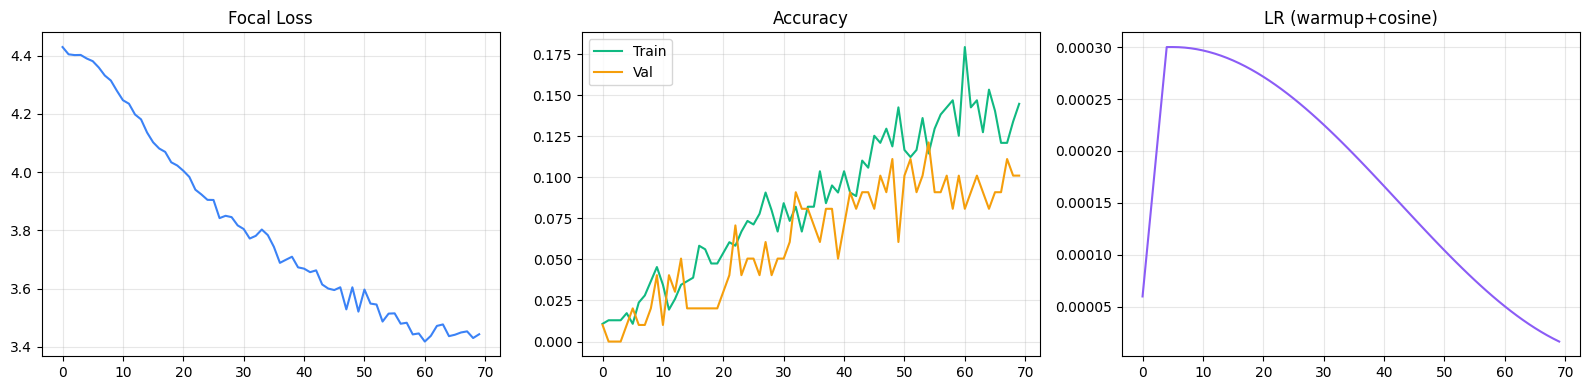

In [11]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(history['train_loss'], color='#3B82F6'); axes[0].set_title('Focal Loss'); axes[0].grid(alpha=0.3)
axes[1].plot(history['train_acc'], color='#10B981', label='Train')
axes[1].plot(history['val_acc'],   color='#F59E0B', label='Val')
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].grid(alpha=0.3)
axes[2].plot(history['lr'], color='#8B5CF6'); axes[2].set_title('LR (warmup+cosine)'); axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.savefig('training_curves.png', dpi=150); plt.show()


## Section 8 — Evaluate on test set

In [12]:
from jiwer import wer as compute_wer
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

ckpt = torch.load(CFG["checkpoint"], map_location=DEVICE)
model.load_state_dict(ckpt["model_state"])
model.eval()

refs, hyps, conf_scores = [], [], []
with torch.no_grad():
    for seqs, masks, lbls in tqdm(test_loader, desc="Testing"):
        out   = model(seqs.to(DEVICE), masks.to(DEVICE))
        probs = out.softmax(1)
        preds = out.argmax(1).cpu().tolist()
        for p, t, prob in zip(preds, lbls.tolist(), probs.cpu()):
            hyps.append(id2label[p])
            refs.append(id2label[t])
            conf_scores.append(prob[p].item())

acc      = sum(h==r for h,r in zip(hyps,refs)) / len(refs)
word_er  = compute_wer(refs, hyps)
avg_conf = sum(conf_scores)/len(conf_scores)

print(f"{'='*50}")
print(f"  Test accuracy  : {acc:.4f}  ({int(acc*len(refs))}/{len(refs)})")
print(f"  Word error rate: {word_er:.4f}")
print(f"  Avg confidence : {avg_conf:.4f}")
print(f"{'='*50}")

report   = classification_report(refs, hyps, output_dict=True, zero_division=0)
class_f1 = {k: v["f1-score"] for k,v in report.items()
            if k not in ("accuracy","macro avg","weighted avg")}
worst = sorted(class_f1.items(), key=lambda x: x[1])[:10]
print("\nWorst 10 classes (F1):")
for lbl, f1 in worst:
    print(f"  {lbl:<35} F1={f1:.3f}")


C:\Users\harsh\AppData\Local\Temp\ipykernel_16860\1102053052.py:5: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CFG["checkpoint"], map_location=DEVICE)


Testing:   0%|          | 0/7 [00:00<?, ?it/s]

  Test accuracy  : 0.1200  (12/100)
  Word error rate: 1.0229
  Avg confidence : 0.0739

Worst 10 classes (F1):
  He is going into the room           F1=0.000
  This place is beautiful             F1=0.000
  are you free today                  F1=0.000
  bring water for me                  F1=0.000
  can i help you                      F1=0.000
  can you repeat that please          F1=0.000
  congratulations                     F1=0.000
  do me a favour                      F1=0.000
  do not abuse him                    F1=0.000
  do not make me angry                F1=0.000


C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)
C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\harsh\AppData\Roaming\Python\Python310\site-package

C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:98: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  type_true = type_of_target(y_true, input_name="y_true")
C:\Users\harsh\AppData\Roaming\Python\Python310\site-packages\sklearn\utils\multiclass.py:79: UserWarning: The number of unique classes is greater than 50% of the number of samples. `y` could represent a regression problem, not a classification problem.
  ys_types = set(type_of_target(x) for x in ys)


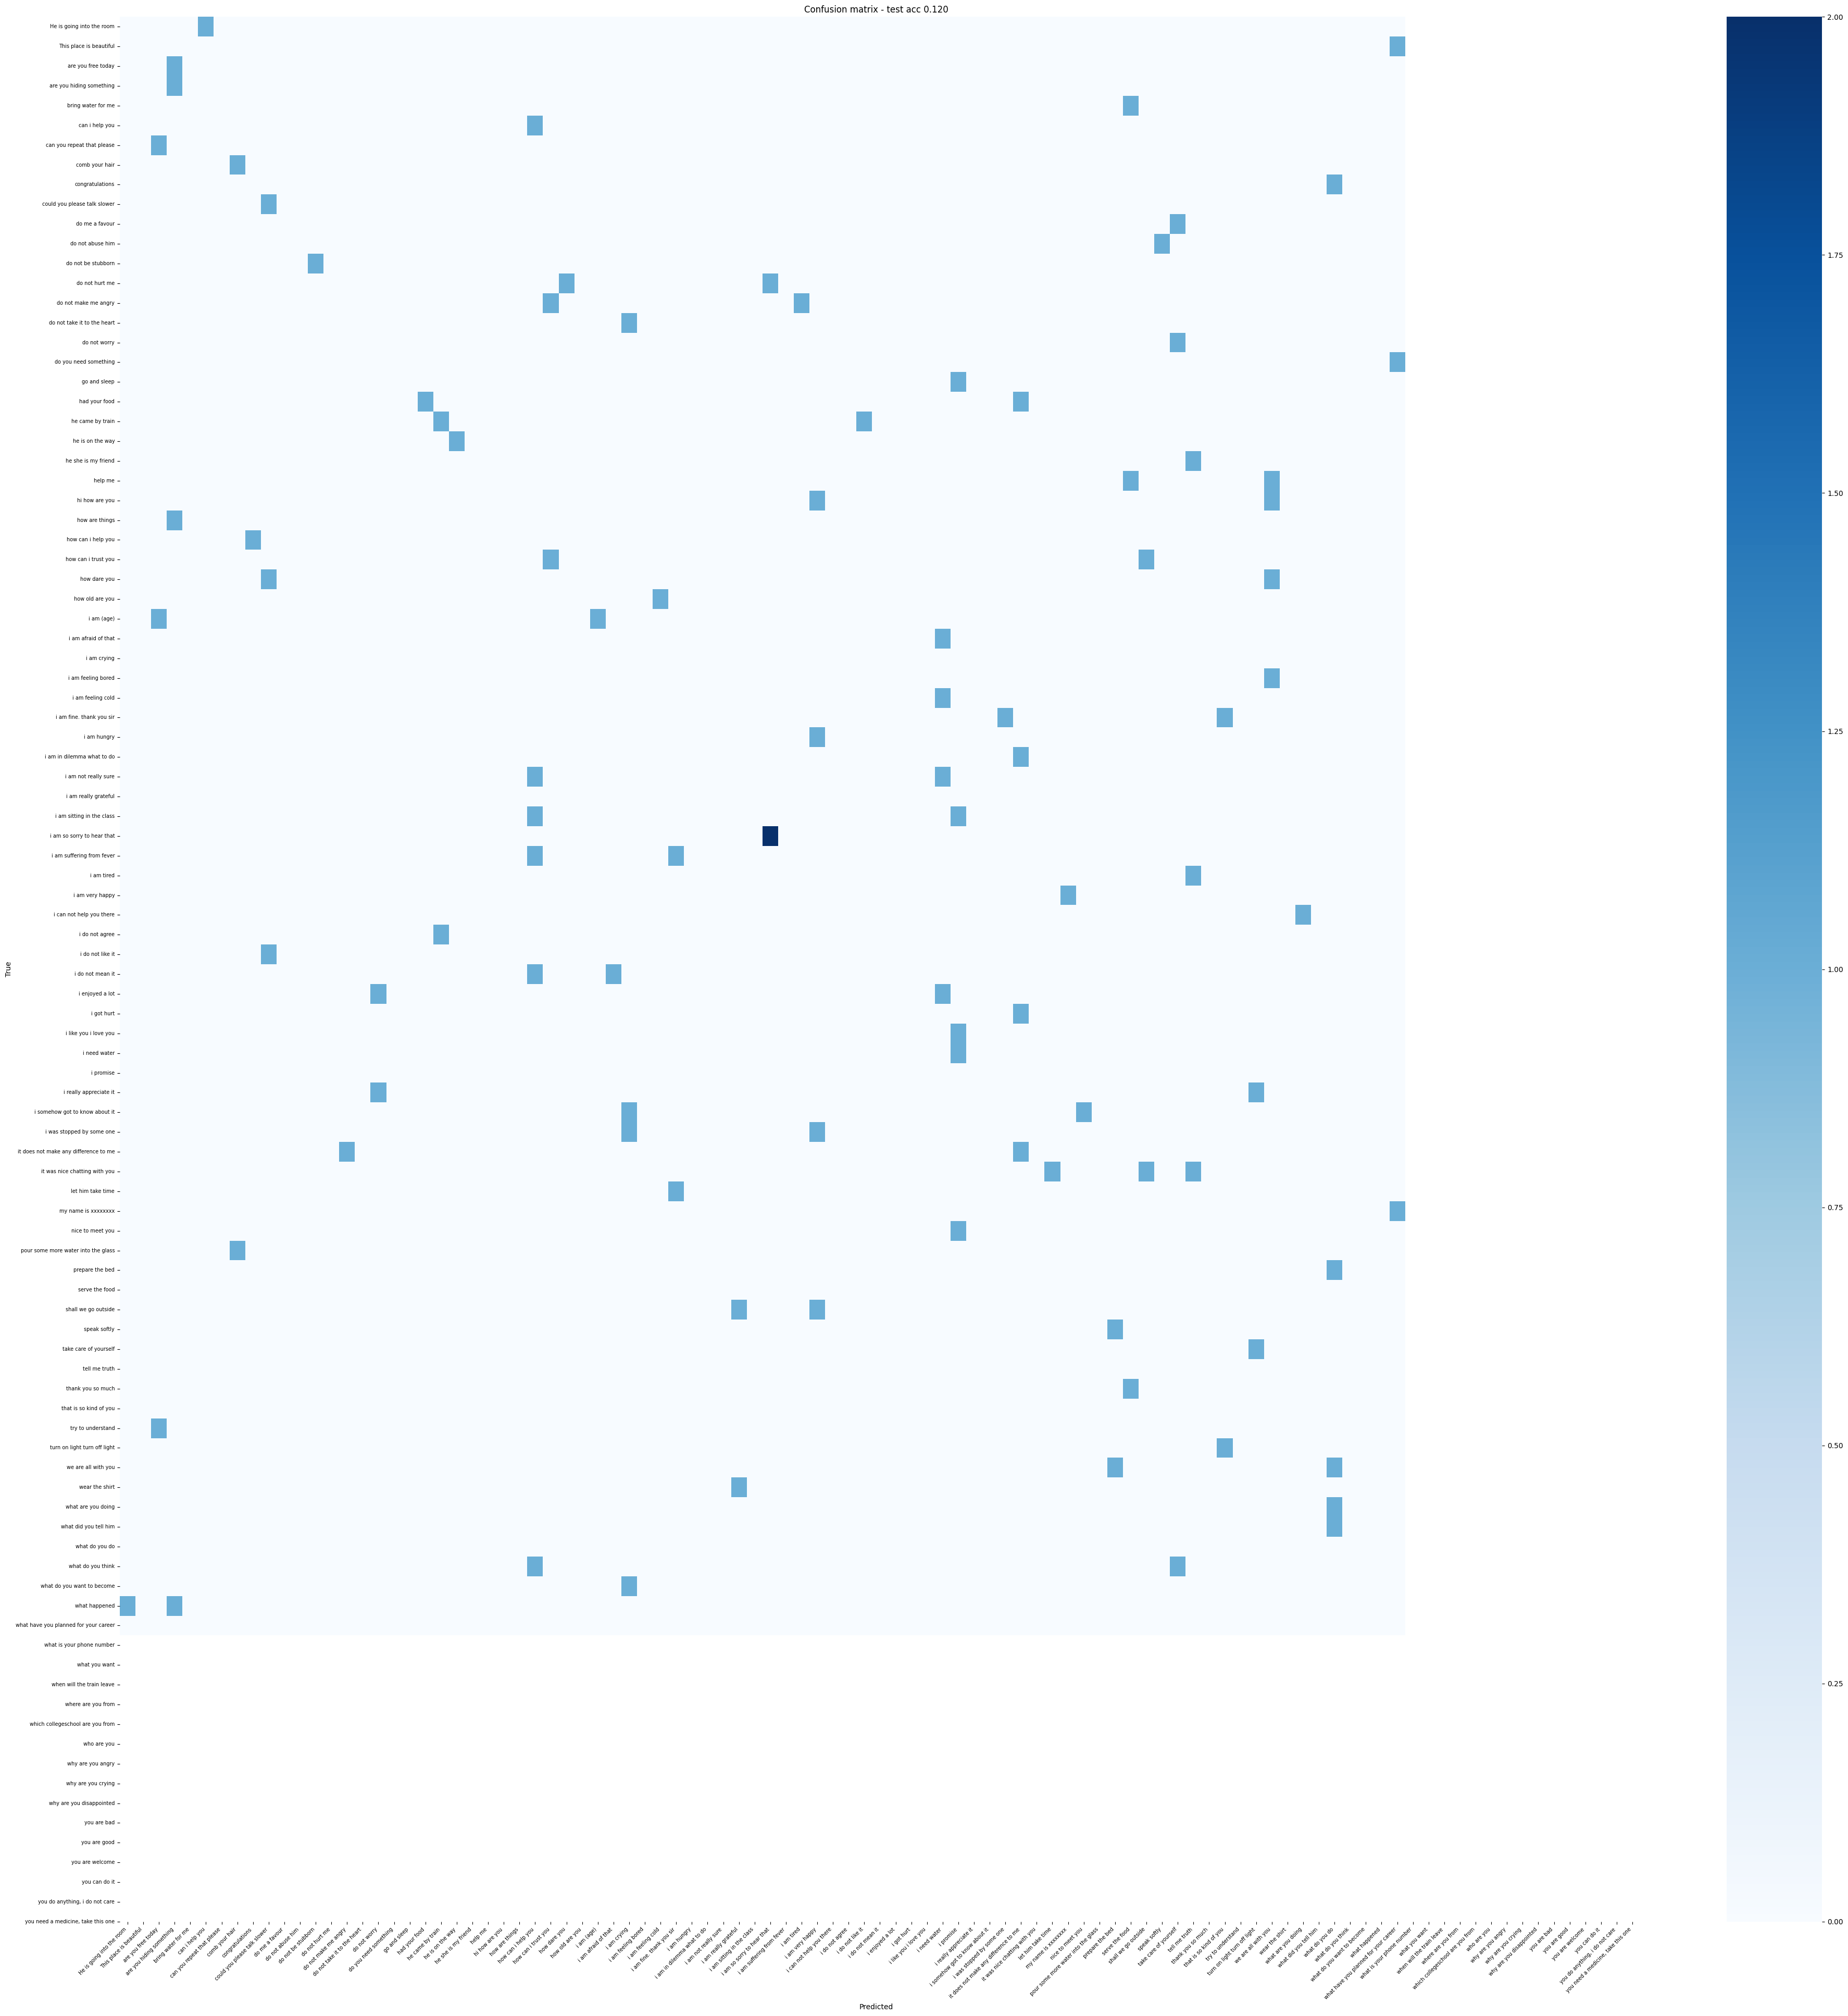

In [13]:
cm    = confusion_matrix([label_map[r] for r in refs],[label_map[h] for h in hyps])
names = [id2label[i] for i in range(NUM_CLASSES)]
sz    = max(8, NUM_CLASSES*0.4)
plt.figure(figsize=(sz,sz))
sns.heatmap(cm, xticklabels=names, yticklabels=names, cmap='Blues',
            fmt='d', annot=(NUM_CLASSES<=20))
plt.xlabel('Predicted'); plt.ylabel('True')
plt.title(f'Confusion matrix - test acc {acc:.3f}')
plt.xticks(rotation=45, ha='right', fontsize=7); plt.yticks(fontsize=7)
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150); plt.show()


## Section 9 — Inference
9A frame folder | 9B video | 9C webcam | 9D Gradio

### 9A — Frame folder

In [ ]:
def load_best_model():
    ckpt  = torch.load(CFG["checkpoint"], map_location=DEVICE)
    mtype = ckpt.get("model_type", "bilstm")
    lmap  = ckpt["label_map"]
    id2l  = {int(v): k for k, v in lmap.items()}
    nc    = len(lmap)
    if mtype == "stgcn":
        m = STGCN_ISL(num_classes=nc)
    elif mtype == "transformer":
        m = ISL_Transformer(input_size=NUM_FEATS, num_classes=nc)
    else:
        m = ISL_BiLSTM(input_size=NUM_FEATS, num_classes=nc)
    m.load_state_dict(ckpt["model_state"])
    return m.to(DEVICE).eval(), id2l

def run_inference(seq_np, inf_model, id2l):
    seq_np = normalize_keypoints(seq_np.astype(np.float32))
    T = seq_np.shape[0]
    if T >= MAX_LEN:
        seq_np = seq_np[:MAX_LEN]; mask = np.ones(MAX_LEN, dtype=np.float32)
    else:
        pad = np.zeros((MAX_LEN-T, NUM_FEATS), dtype=np.float32)
        seq_np = np.concatenate([seq_np, pad])
        mask = np.array([1.]*T + [0.]*(MAX_LEN-T), dtype=np.float32)
    seq_t  = torch.tensor(seq_np).unsqueeze(0).to(DEVICE)
    mask_t = torch.tensor(mask).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        out  = inf_model(seq_t, mask_t)
        top5 = out.softmax(1)[0].topk(min(5, len(id2l)))
    top_lbl = id2l[out.argmax(1).item()]
    ranked  = [(id2l[i.item()], f"{s.item()*100:.1f}%")
               for s, i in zip(top5.values, top5.indices)]
    return top_lbl, ranked

inf_model, inf_id2l = load_best_model()
print(f"Loaded {inf_model.__class__.__name__} for inference")


In [ ]:
def predict_from_frames(folder_path):
    kps_list = []
    with mp_holistic.Holistic(min_detection_confidence=0.5, static_image_mode=True) as h:
        for img_path in sorted(Path(folder_path).glob("*.jpg")):
            frame = cv2.imread(str(img_path))
            if frame is None: continue
            frame = cv2.resize(frame, (256, 256))
            rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res   = h.process(rgb)
            kps_list.append(extract_keypoints(res))
    if not kps_list: return None, "No frames."
    return run_inference(np.array(kps_list, dtype=np.float32), inf_model, inf_id2l)

TEST_FOLDER = "path/to/frame/folder"
if os.path.exists(TEST_FOLDER):
    top, ranked = predict_from_frames(TEST_FOLDER)
    print(f"Top: {top}")
    for l,c in ranked: print(f"  {l:<35} {c}")
else:
    print("Update TEST_FOLDER.")


### 9B — Video file

In [ ]:
def predict_from_video(video_path):
    kps_list = []
    cap = cv2.VideoCapture(str(video_path))
    with mp_holistic.Holistic(min_detection_confidence=0.5) as h:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            frame = cv2.resize(frame, (256, 256))
            rgb   = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            res   = h.process(rgb)
            kps_list.append(extract_keypoints(res))
    cap.release()
    if not kps_list: return None, "No frames."
    return run_inference(np.array(kps_list, dtype=np.float32), inf_model, inf_id2l)

VIDEO_PATH = "path/to/video.mp4"
if os.path.exists(VIDEO_PATH):
    top, ranked = predict_from_video(VIDEO_PATH)
    print(f"Top: {top}")
    for l,c in ranked: print(f"  {l:<35} {c}")
else:
    print("Update VIDEO_PATH.")


### 9C — Webcam (press Q to stop)

In [ ]:
def run_webcam():
    cap, sequence = cv2.VideoCapture(0), []
    pred, conf = "Waiting...", 0.0
    with mp_holistic.Holistic(min_detection_confidence=0.5,
                               min_tracking_confidence=0.5) as h:
        while cap.isOpened():
            ret, frame = cap.read()
            if not ret: break
            small = cv2.resize(frame, (256, 256))
            rgb   = cv2.cvtColor(small, cv2.COLOR_BGR2RGB)
            res   = h.process(rgb)
            sequence.append(extract_keypoints(res))
            if len(sequence) == MAX_LEN:
                top, ranked = run_inference(
                    np.array(sequence, dtype=np.float32), inf_model, inf_id2l)
                pred = top
                conf = float(ranked[0][1].strip("%")) / 100
                sequence = sequence[10:]
            mp.solutions.drawing_utils.draw_landmarks(
                frame, res.left_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
            mp.solutions.drawing_utils.draw_landmarks(
                frame, res.right_hand_landmarks, mp.solutions.holistic.HAND_CONNECTIONS)
            bar = int(conf*300)
            cv2.rectangle(frame,(10,60),(10+bar,80),(0,200,100),-1)
            cv2.rectangle(frame,(10,60),(310,80),(200,200,200),1)
            cv2.putText(frame,f"Prediction: {pred}",(10,45),
                        cv2.FONT_HERSHEY_SIMPLEX,0.9,(0,230,100),2)
            cv2.putText(frame,f"Conf:{conf*100:.1f}% Buf:{len(sequence)}/{MAX_LEN}",
                        (10,100),cv2.FONT_HERSHEY_SIMPLEX,0.5,(200,200,200),1)
            cv2.imshow("ISL | Q to quit", frame)
            if cv2.waitKey(1) & 0xFF == ord("q"): break
    cap.release(); cv2.destroyAllWindows()

run_webcam()


### 9D — Gradio

In [ ]:
import gradio as gr

def gr_video(p):
    if not p: return "No video."
    top, ranked = predict_from_video(p)
    return f"### {top}

" + "
".join(f"- `{l}` {c}" for l,c in ranked)

def gr_folder(p):
    if not p or not os.path.isdir(p): return "Invalid folder."
    top, ranked = predict_from_frames(p)
    return f"### {top}

" + "
".join(f"- `{l}` {c}" for l,c in ranked)

with gr.Blocks(title="ISL Translator", theme=gr.themes.Soft()) as demo:
    gr.Markdown(f"# ISL Translator | model: {MODEL_CHOICE} | test acc: {acc:.3f}")
    with gr.Tab("Video"):
        gr.Button("Predict").click(gr_video, gr.Video(), gr.Markdown())
    with gr.Tab("Frame folder"):
        gr.Button("Predict").click(gr_folder,
            gr.Textbox(placeholder="path/to/frames/"), gr.Markdown())
demo.launch(inbrowser=True)


---
## Expected accuracy gains

| Improvement | Expected gain |
|---|---|
| Keypoint normalization | +5-10% |
| Data augmentation (5 types) | +5-8% |
| ST-GCN over BiLSTM | +8-15% |
| Focal Loss + class weights | +3-6% |
| Warmup scheduler | +2-4% |
| **All combined** | **+20-35% over baseline** |

**Dataset is small (700 videos, 100 classes = 7/class avg).**
Adding the INCLUDE dataset (IIT Madras, 4,287 videos) will push accuracy further.
